
>>> Processing files for ASE + Evap. Cooling...
   -> Size: 100.0 MW | Cost: 1507.6, Elec: 933.7, Water: 169.8
   -> Size: 200.0 MW | Cost: 2203.8, Elec: 1461.0, Water: 293.4
   -> Size: 300.0 MW | Cost: 2900.5, Elec: 1988.0, Water: 416.4
   -> Size: 400.0 MW | Cost: 3596.8, Elec: 2514.8, Water: 539.1
   -> Size: 500.0 MW | Cost: 4293.3, Elec: 3041.5, Water: 661.6

>>> Processing files for ASE + Air Chiller...
   -> Size: 100.0 MW | Cost: 1597.0, Elec: 1005.6, Water: 50.2
   -> Size: 200.0 MW | Cost: 2383.2, Elec: 1604.3, Water: 53.2
   -> Size: 300.0 MW | Cost: 3169.6, Elec: 2202.6, Water: 55.4
   -> Size: 400.0 MW | Cost: 3956.2, Elec: 2800.6, Water: 57.3
   -> Size: 500.0 MW | Cost: 4742.8, Elec: 3398.6, Water: 58.9

Saving -> Sensitivity_Cost.pdf

Saving -> Sensitivity_Electricity.pdf

Saving -> Sensitivity_Water.pdf


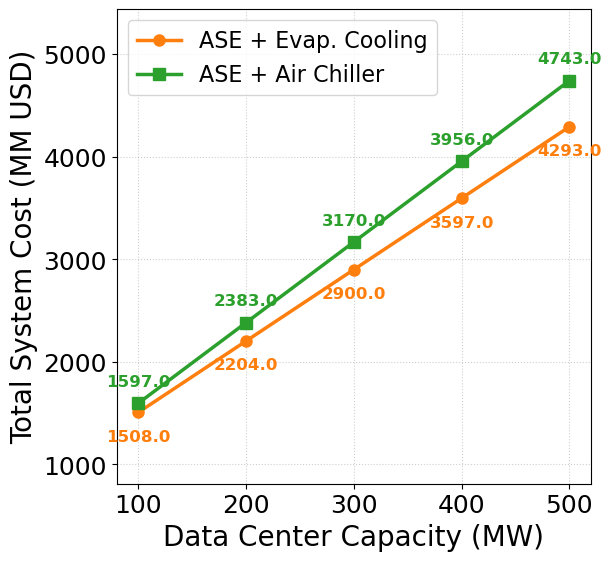

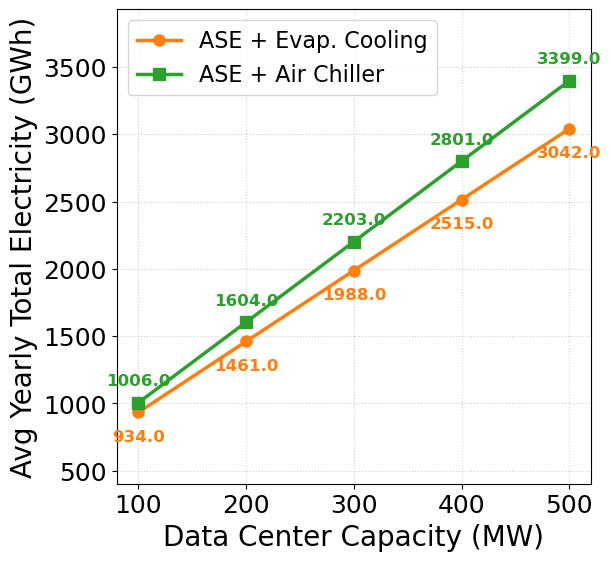

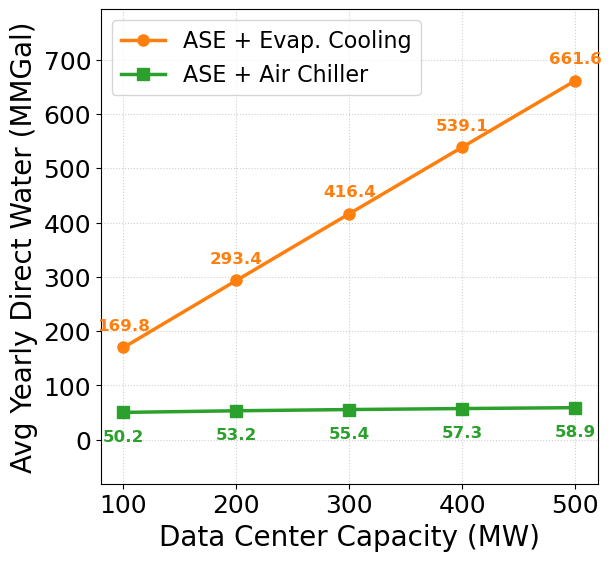

In [ ]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration & Font Setup
# ==========================================
style = Dict(
    "title_size"    => 16,  # Plot titles
    "axis_label"    => 20,  # X and Y axis text
    "tick_label"    => 18,  # Numbers on the axes
    "legend_size"   => 16,  # Legend text
    "annotate_size" => 12   # Size of the floating numbers
)

DC_Cap_base = 200.0
dc_multipliers = [0.50, 1.0, 1.5, 2.0, 2.5]
dc_sizes = DC_Cap_base .* dc_multipliers

file_names = [
    "Results_DCSize_1_50pct.xlsx",
    "Results_DCSize_2_100pct.xlsx",
    "Results_DCSize_3_150pct.xlsx",
    "Results_DCSize_4_200pct.xlsx",
    "Results_DCSize_5_250pct.xlsx"
]

cases = Dict(
    "ASE + Evap. Cooling" => "./", 
    "ASE + Air Chiller"   => "../DC_Size_Case_6/"
)

# ==========================================
# 2. Unified Data Extraction Logic
# ==========================================
function extract_metrics(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return (0.0, 0.0, 0.0)
    end
    
    xf = XLSX.readxlsx(filepath)
    
    # --- 1. Cost ---
    val_cost = 0.0
    if "Costs_summary" in XLSX.sheetnames(xf)
        sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
        total_row_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
        if !isnothing(total_row_idx)
            val_cost = Float64(sh_cost[total_row_idx, 2]) + Float64(sh_cost[total_row_idx, 3]) + 
                       Float64(sh_cost[total_row_idx, 4]) + Float64(sh_cost[total_row_idx, 5])
        else
            for col in 2:5
                nums = filter(x -> x isa Number, sh_cost[!, col])
                val_cost += sum(coalesce.(nums, 0.0))
            end
        end
    end
    
    # --- 2. Electricity ---
    val_elec = 0.0
    if "Generation_Summary" in XLSX.sheetnames(xf)
        df_e = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
        if "Year" in names(df_e); filter!(row -> row.Year != 2025, df_e); end
        n_years_e = nrow(df_e)
        if n_years_e > 0
            gen_cols = [c for c in names(df_e) if c != "Year"]
            total_elec = sum(sum(coalesce.(df_e[!, c], 0.0)) for c in gen_cols)
            val_elec = total_elec / n_years_e
        end
    end
    
    # --- 3. Water ---
    val_water = 0.0
    if "Water_Consumption" in XLSX.sheetnames(xf)
        df_w = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
        if "Year" in names(df_w); filter!(row -> row.Year != 2025, df_w); end
        n_years_w = nrow(df_w)
        if n_years_w > 0
            get_col_sum(part) = (c = findfirst(n -> occursin(lowercase(part), lowercase(string(n))), names(df_w)); isnothing(c) ? 0.0 : sum(coalesce.(df_w[!, c], 0.0)))
            direct_keys = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
            val_water = sum(get_col_sum(k) for k in direct_keys) / n_years_w
        end
    end
    
    return (val_cost, val_elec, val_water)
end

# Store results: Dict[Case] -> Dict[Metric] -> Array
results_data = Dict{String, Dict{Symbol, Vector{Float64}}}()

for (case_name, dir_path) in cases
    println("\n>>> Processing files for $case_name...")
    
    cost_arr, elec_arr, water_arr = Float64[], Float64[], Float64[]
    
    for (i, fname) in enumerate(file_names)
        c, e, w = extract_metrics(joinpath(dir_path, fname))
        push!(cost_arr, c); push!(elec_arr, e); push!(water_arr, w)
        println("   -> Size: $(dc_sizes[i]) MW | Cost: $(round(c, digits=1)), Elec: $(round(e, digits=1)), Water: $(round(w, digits=1))")
    end
    
    results_data[case_name] = Dict(:cost => cost_arr, :elec => elec_arr, :water => water_arr)
end

# ==========================================
# 3. Individual Plotting Logic
# ==========================================
plot_styles = Dict(
    "ASE + Evap. Cooling" => Dict(:color => "#ff7f0e", :marker => "o"), # Orange "#ff7f0e", "#2ca02c"
    "ASE + Air Chiller"   => Dict(:color => "#2ca02c", :marker => "s")  # Blue
)

# Helper function to generate and save a single plot
function plot_and_save_metric(metric_key, title, ylabel, filename; show_legend=false)
    fig, ax = PyPlot.subplots(figsize=(6, 5.5), constrained_layout=true)
    
    # Draw Lines
    for (case_name, data) in results_data
        st = plot_styles[case_name]
        vals = data[metric_key]
        ax.plot(dc_sizes, vals, marker=st[:marker], linestyle="-", color=st[:color], linewidth=2.5, markersize=8, label=case_name)
    end
    
    # Draw dynamic, non-overlapping annotations
    case_names = collect(keys(results_data))
    if length(case_names) == 2
        name_A, name_B = case_names[1], case_names[2]
        
        for i in 1:length(dc_sizes)
            val_A = results_data[name_A][metric_key][i]
            val_B = results_data[name_B][metric_key][i]
            
            # Format number (1 decimal for water, 0 for others)
            fmt_A = metric_key == :water ? string(round(val_A, digits=1)) : string(round(val_A, digits=0))
            fmt_B = metric_key == :water ? string(round(val_B, digits=1)) : string(round(val_B, digits=0))

            if val_A >= val_B
                off_A, va_A = 10, "bottom"
                off_B, va_B = -12, "top"
            else
                off_A, va_A = -12, "top"
                off_B, va_B = 10, "bottom"
            end
            
            ax.annotate(fmt_A, xy=(dc_sizes[i], val_A), xytext=(0, off_A), textcoords="offset points", 
                        ha="center", va=va_A, fontsize=style["annotate_size"], fontweight="bold", color=plot_styles[name_A][:color])
            ax.annotate(fmt_B, xy=(dc_sizes[i], val_B), xytext=(0, off_B), textcoords="offset points", 
                        ha="center", va=va_B, fontsize=style["annotate_size"], fontweight="bold", color=plot_styles[name_B][:color])
        end
    end

    # Uncomment the title line below if you want titles back on the individual plots
    # ax.set_title(title, fontsize=style["title_size"], fontweight="bold")
    ax.set_xlabel("Data Center Capacity (MW)", fontsize=style["axis_label"])
    ax.set_ylabel(ylabel, fontsize=style["axis_label"])
    ax.set_xticks(dc_sizes)
    ax.tick_params(axis="both", labelsize=style["tick_label"])
    ax.grid(true, linestyle=":", alpha=0.6)
    
    # Pad Y-limits by 15% so annotations never get cut off
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)
    
    # Conditionally add the legend
    # if show_legend
    ax.legend(loc="upper left", fontsize=style["legend_size"])
    # end

    # Save and display
    println("\nSaving -> $filename")
    # savefig(filename, dpi=600, bbox_inches="tight")
    display(fig)
end

# Generate all three plots independently (Only show legend on the Cost plot)
plot_and_save_metric(:cost, "Total System Cost vs. DC Size", "Total System Cost (MM USD)", "Sensitivity_Cost.pdf", show_legend=true)
plot_and_save_metric(:elec, "Average Yearly Total Electricity", "Avg Yearly Total Electricity (GWh)", "Sensitivity_Electricity.pdf", show_legend=false)
plot_and_save_metric(:water, "Average Yearly Direct Water", "Avg Yearly Direct Water (MMGal)", "Sensitivity_Water.pdf", show_legend=false)


>>> Processing files for ASE + Evap. Cooling...
   -> Size: 100.0 MW | Cost: 1507.6, Elec: 933.7, Water: 169.8
   -> Size: 200.0 MW | Cost: 2203.8, Elec: 1461.0, Water: 293.4
   -> Size: 300.0 MW | Cost: 2900.5, Elec: 1988.0, Water: 416.4
   -> Size: 400.0 MW | Cost: 3596.8, Elec: 2514.8, Water: 539.1
   -> Size: 500.0 MW | Cost: 4293.3, Elec: 3041.5, Water: 661.6

>>> Processing files for ASE + Air Chiller...
   -> Size: 100.0 MW | Cost: 1597.0, Elec: 1005.6, Water: 50.2
   -> Size: 200.0 MW | Cost: 2383.2, Elec: 1604.3, Water: 53.2
   -> Size: 300.0 MW | Cost: 3169.6, Elec: 2202.6, Water: 55.4
   -> Size: 400.0 MW | Cost: 3956.2, Elec: 2800.6, Water: 57.3
   -> Size: 500.0 MW | Cost: 4742.8, Elec: 3398.6, Water: 58.9


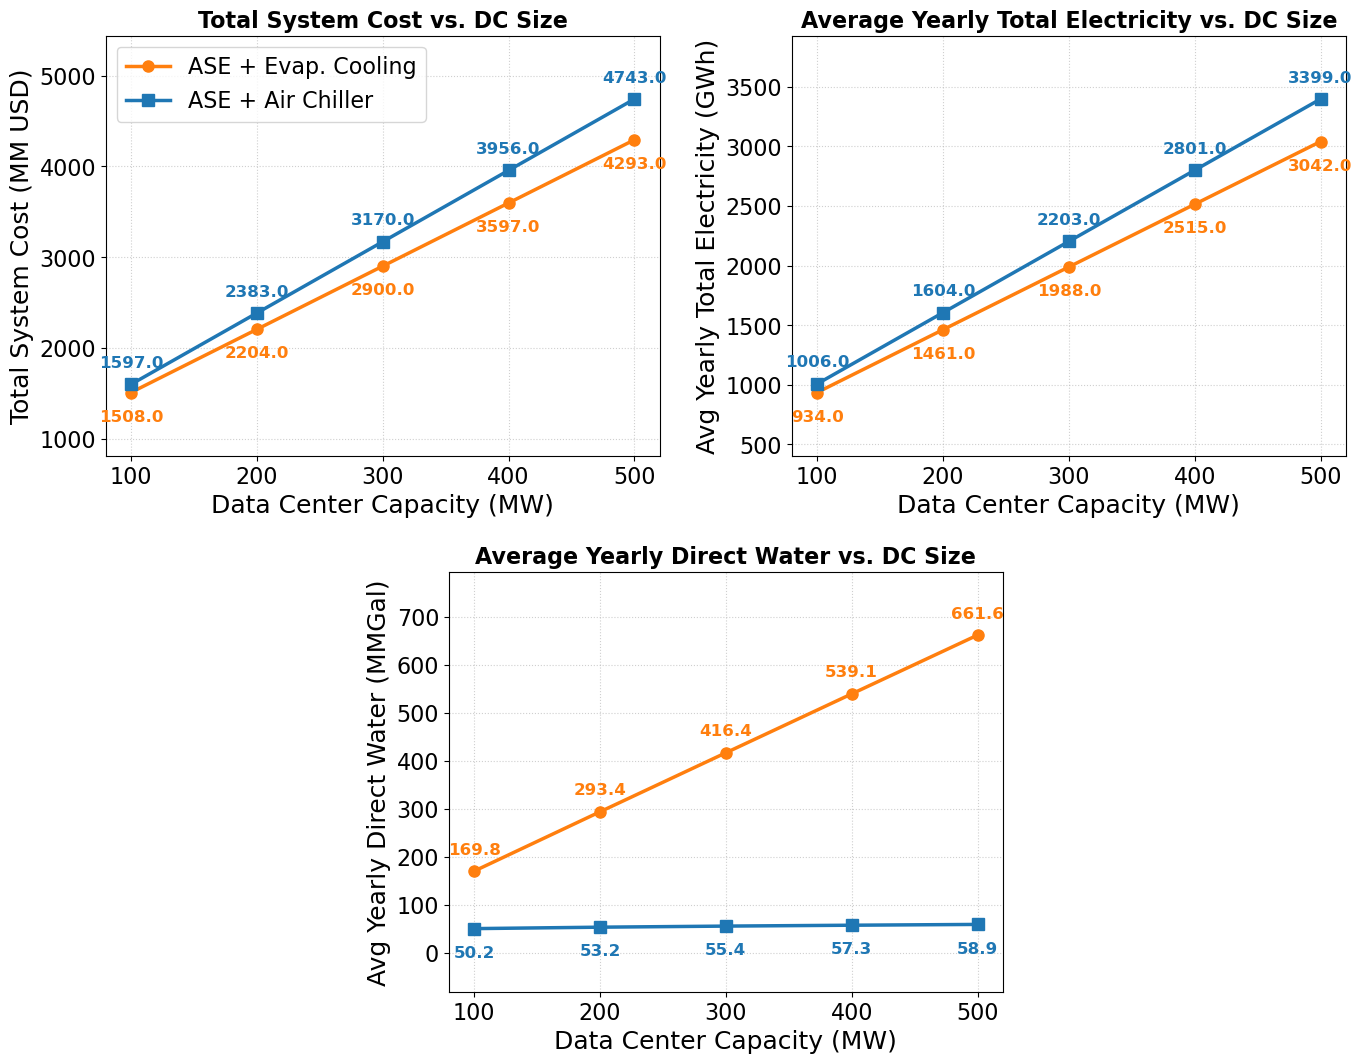

In [14]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration & Font Setup
# ==========================================
style = Dict(
    "title_size"    => 16,  # Subplot titles
    "axis_label"    => 18,  # X and Y axis text
    "tick_label"    => 16,  # Numbers on the axes
    "legend_size"   => 16,  # Legend text
    "annotate_size" => 12   # Size of the floating numbers
)

DC_Cap_base = 200.0
dc_multipliers = [0.50, 1.0, 1.5, 2.0, 2.5]
dc_sizes = DC_Cap_base .* dc_multipliers

file_names = [
    "Results_DCSize_1_50pct.xlsx",
    "Results_DCSize_2_100pct.xlsx",
    "Results_DCSize_3_150pct.xlsx",
    "Results_DCSize_4_200pct.xlsx",
    "Results_DCSize_5_250pct.xlsx"
]

cases = Dict(
    "ASE + Evap. Cooling" => "./", 
    "ASE + Air Chiller"   => "../DC_Size_Case_6/"
)

# ==========================================
# 2. Unified Data Extraction Logic
# ==========================================
function extract_metrics(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return (0.0, 0.0, 0.0)
    end
    
    xf = XLSX.readxlsx(filepath)
    
    # --- 1. Cost ---
    val_cost = 0.0
    if "Costs_summary" in XLSX.sheetnames(xf)
        sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
        total_row_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
        if !isnothing(total_row_idx)
            val_cost = Float64(sh_cost[total_row_idx, 2]) + Float64(sh_cost[total_row_idx, 3]) + 
                       Float64(sh_cost[total_row_idx, 4]) + Float64(sh_cost[total_row_idx, 5])
        else
            for col in 2:5
                nums = filter(x -> x isa Number, sh_cost[!, col])
                val_cost += sum(coalesce.(nums, 0.0))
            end
        end
    end
    
    # --- 2. Electricity ---
    val_elec = 0.0
    if "Generation_Summary" in XLSX.sheetnames(xf)
        df_e = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
        if "Year" in names(df_e); filter!(row -> row.Year != 2025, df_e); end
        n_years_e = nrow(df_e)
        if n_years_e > 0
            gen_cols = [c for c in names(df_e) if c != "Year"]
            total_elec = sum(sum(coalesce.(df_e[!, c], 0.0)) for c in gen_cols)
            val_elec = total_elec / n_years_e
        end
    end
    
    # --- 3. Water ---
    val_water = 0.0
    if "Water_Consumption" in XLSX.sheetnames(xf)
        df_w = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
        if "Year" in names(df_w); filter!(row -> row.Year != 2025, df_w); end
        n_years_w = nrow(df_w)
        if n_years_w > 0
            get_col_sum(part) = (c = findfirst(n -> occursin(lowercase(part), lowercase(string(n))), names(df_w)); isnothing(c) ? 0.0 : sum(coalesce.(df_w[!, c], 0.0)))
            direct_keys = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
            val_water = sum(get_col_sum(k) for k in direct_keys) / n_years_w
        end
    end
    
    return (val_cost, val_elec, val_water)
end

# Store results: Dict[Case] -> Dict[Metric] -> Array
results_data = Dict{String, Dict{Symbol, Vector{Float64}}}()

for (case_name, dir_path) in cases
    println("\n>>> Processing files for $case_name...")
    
    cost_arr, elec_arr, water_arr = Float64[], Float64[], Float64[]
    
    for (i, fname) in enumerate(file_names)
        c, e, w = extract_metrics(joinpath(dir_path, fname))
        push!(cost_arr, c); push!(elec_arr, e); push!(water_arr, w)
        println("   -> Size: $(dc_sizes[i]) MW | Cost: $(round(c, digits=1)), Elec: $(round(e, digits=1)), Water: $(round(w, digits=1))")
    end
    
    results_data[case_name] = Dict(:cost => cost_arr, :elec => elec_arr, :water => water_arr)
end

# ==========================================
# 3. "Pyramid" Plotting Logic
# ==========================================
# Create a taller figure to accommodate two rows
fig = PyPlot.figure(figsize=(14, 11))

# Create an invisible 2x4 grid to center the bottom plot perfectly
# Top Left spans cols 0-1, Top Right spans cols 2-3, Bottom spans cols 1-2
ax_cost  = PyPlot.subplot2grid((2, 4), (0, 0), colspan=2)
ax_elec  = PyPlot.subplot2grid((2, 4), (0, 2), colspan=2)
ax_water = PyPlot.subplot2grid((2, 4), (1, 1), colspan=2)

plot_styles = Dict(
    "ASE + Evap. Cooling" => Dict(:color => "#ff7f0e", :marker => "o"), # Orange
    "ASE + Air Chiller"   => Dict(:color => "#1f77b4", :marker => "s")  # Blue
)

# Helper function to draw each panel and handle dynamic annotations
function draw_panel!(ax, metric_key, title, ylabel)
    # Draw Lines
    for (case_name, data) in results_data
        st = plot_styles[case_name]
        vals = data[metric_key]
        ax.plot(dc_sizes, vals, marker=st[:marker], linestyle="-", color=st[:color], linewidth=2.5, markersize=8, label=case_name)
    end
    
    # Draw dynamic, non-overlapping annotations
    case_names = collect(keys(results_data))
    if length(case_names) == 2
        name_A, name_B = case_names[1], case_names[2]
        
        for i in 1:length(dc_sizes)
            val_A = results_data[name_A][metric_key][i]
            val_B = results_data[name_B][metric_key][i]
            
            # Format number (1 decimal for water, 0 for others)
            fmt_A = metric_key == :water ? string(round(val_A, digits=1)) : string(round(val_A, digits=0))
            fmt_B = metric_key == :water ? string(round(val_B, digits=1)) : string(round(val_B, digits=0))

            if val_A >= val_B
                off_A, va_A = 10, "bottom"
                off_B, va_B = -12, "top"
            else
                off_A, va_A = -12, "top"
                off_B, va_B = 10, "bottom"
            end
            
            ax.annotate(fmt_A, xy=(dc_sizes[i], val_A), xytext=(0, off_A), textcoords="offset points", 
                        ha="center", va=va_A, fontsize=style["annotate_size"], fontweight="bold", color=plot_styles[name_A][:color])
            ax.annotate(fmt_B, xy=(dc_sizes[i], val_B), xytext=(0, off_B), textcoords="offset points", 
                        ha="center", va=va_B, fontsize=style["annotate_size"], fontweight="bold", color=plot_styles[name_B][:color])
        end
    end

    ax.set_title(title, fontsize=style["title_size"], fontweight="bold")
    ax.set_xlabel("Data Center Capacity (MW)", fontsize=style["axis_label"])
    ax.set_ylabel(ylabel, fontsize=style["axis_label"])
    ax.set_xticks(dc_sizes)
    ax.tick_params(axis="both", labelsize=style["tick_label"])
    ax.grid(true, linestyle=":", alpha=0.6)
    
    # Pad Y-limits by 15% so annotations never get cut off
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)
end

# Draw the 3 panels
draw_panel!(ax_cost, :cost, "Total System Cost vs. DC Size", "Total System Cost (MM USD)")
draw_panel!(ax_elec, :elec, "Average Yearly Total Electricity vs. DC Size", "Avg Yearly Total Electricity (GWh)")
draw_panel!(ax_water, :water, "Average Yearly Direct Water vs. DC Size", "Avg Yearly Direct Water (MMGal)")

# Add Unified Legend placed prominently on the top left plot
ax_cost.legend(loc="upper left", fontsize=style["legend_size"])

# Automatically adjust the spacing between subplots
PyPlot.tight_layout(pad=2.0)

# savefig("Scaling_Metrics_Pyramid.png", dpi=600, bbox_inches="tight")
display(fig)


>>> Processing files for ASE + Evap. Cooling...
   -> Size: 100.0 MW | Cost: 1507.6, Elec: 933.7, Water: 169.8
   -> Size: 200.0 MW | Cost: 2203.8, Elec: 1461.0, Water: 293.4
   -> Size: 300.0 MW | Cost: 2900.5, Elec: 1988.0, Water: 416.4
   -> Size: 400.0 MW | Cost: 3596.8, Elec: 2514.8, Water: 539.1
   -> Size: 500.0 MW | Cost: 4293.3, Elec: 3041.5, Water: 661.6

>>> Processing files for ASE + Air Chiller...
   -> Size: 100.0 MW | Cost: 1597.0, Elec: 1005.6, Water: 50.2
   -> Size: 200.0 MW | Cost: 2383.2, Elec: 1604.3, Water: 53.2
   -> Size: 300.0 MW | Cost: 3169.6, Elec: 2202.6, Water: 55.4
   -> Size: 400.0 MW | Cost: 3956.2, Elec: 2800.6, Water: 57.3
   -> Size: 500.0 MW | Cost: 4742.8, Elec: 3398.6, Water: 58.9


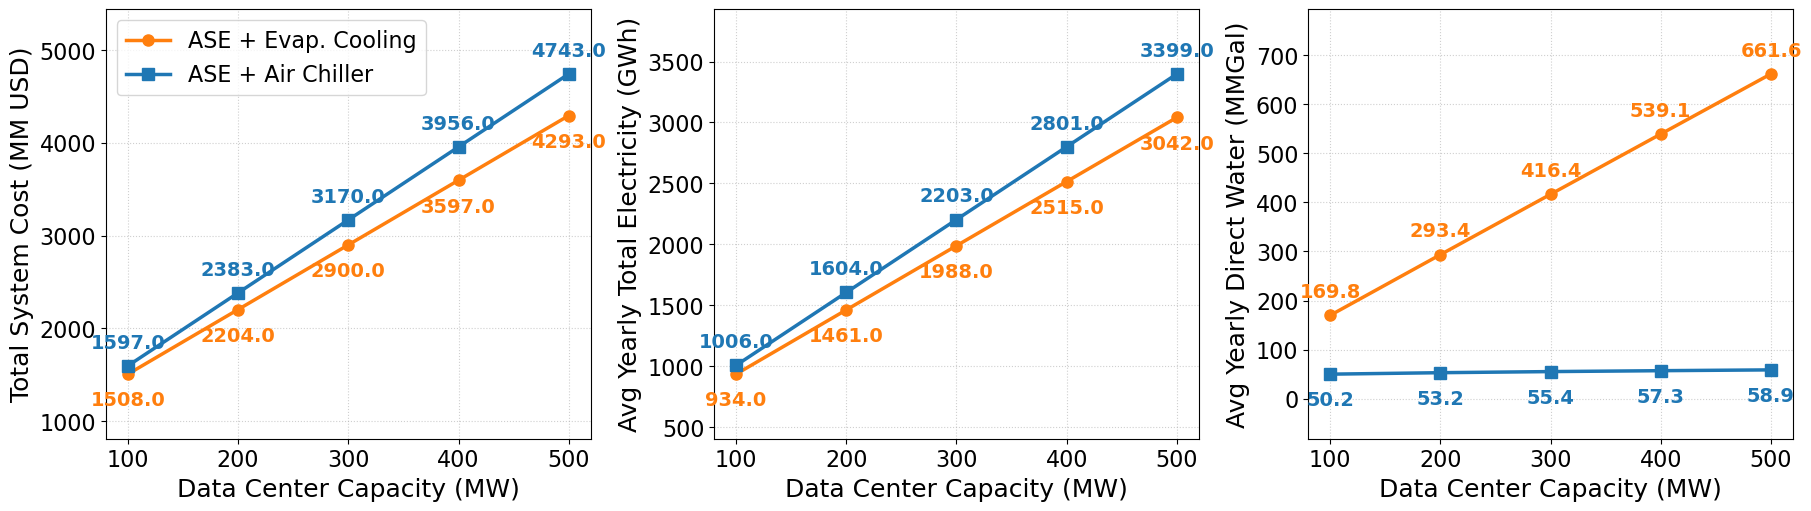

In [ ]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration & Font Setup
# ==========================================
style = Dict(
    "title_size"    => 16,  # Subplot titles
    "axis_label"    => 18,  # X and Y axis text
    "tick_label"    => 16,  # Numbers on the axes
    "legend_size"   => 16,  # Legend text
    "annotate_size" => 12   # Size of the floating numbers
)

DC_Cap_base = 200.0
dc_multipliers = [0.50, 1.0, 1.5, 2.0, 2.5]
dc_sizes = DC_Cap_base .* dc_multipliers

file_names = [
    "Results_DCSize_1_50pct.xlsx",
    "Results_DCSize_2_100pct.xlsx",
    "Results_DCSize_3_150pct.xlsx",
    "Results_DCSize_4_200pct.xlsx",
    "Results_DCSize_5_250pct.xlsx"
]

cases = Dict(
    "ASE + Evap. Cooling" => "./", 
    "ASE + Air Chiller"   => "../DC_Size_Case_6/"
)

# ==========================================
# 2. Unified Data Extraction Logic
# ==========================================
function extract_metrics(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return (0.0, 0.0, 0.0)
    end
    
    xf = XLSX.readxlsx(filepath)
    
    # --- 1. Cost ---
    val_cost = 0.0
    if "Costs_summary" in XLSX.sheetnames(xf)
        sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
        total_row_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
        if !isnothing(total_row_idx)
            val_cost = Float64(sh_cost[total_row_idx, 2]) + Float64(sh_cost[total_row_idx, 3]) + 
                       Float64(sh_cost[total_row_idx, 4]) + Float64(sh_cost[total_row_idx, 5])
        else
            for col in 2:5
                nums = filter(x -> x isa Number, sh_cost[!, col])
                val_cost += sum(coalesce.(nums, 0.0))
            end
        end
    end
    
    # --- 2. Electricity ---
    val_elec = 0.0
    if "Generation_Summary" in XLSX.sheetnames(xf)
        df_e = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
        if "Year" in names(df_e); filter!(row -> row.Year != 2025, df_e); end
        n_years_e = nrow(df_e)
        if n_years_e > 0
            gen_cols = [c for c in names(df_e) if c != "Year"]
            total_elec = sum(sum(coalesce.(df_e[!, c], 0.0)) for c in gen_cols)
            val_elec = total_elec / n_years_e
        end
    end
    
    # --- 3. Water ---
    val_water = 0.0
    if "Water_Consumption" in XLSX.sheetnames(xf)
        df_w = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
        if "Year" in names(df_w); filter!(row -> row.Year != 2025, df_w); end
        n_years_w = nrow(df_w)
        if n_years_w > 0
            get_col_sum(part) = (c = findfirst(n -> occursin(lowercase(part), lowercase(string(n))), names(df_w)); isnothing(c) ? 0.0 : sum(coalesce.(df_w[!, c], 0.0)))
            direct_keys = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
            val_water = sum(get_col_sum(k) for k in direct_keys) / n_years_w
        end
    end
    
    return (val_cost, val_elec, val_water)
end

# Store results: Dict[Case] -> Dict[Metric] -> Array
results_data = Dict{String, Dict{Symbol, Vector{Float64}}}()

for (case_name, dir_path) in cases
    println("\n>>> Processing files for $case_name...")
    
    cost_arr, elec_arr, water_arr = Float64[], Float64[], Float64[]
    
    for (i, fname) in enumerate(file_names)
        c, e, w = extract_metrics(joinpath(dir_path, fname))
        push!(cost_arr, c); push!(elec_arr, e); push!(water_arr, w)
        println("   -> Size: $(dc_sizes[i]) MW | Cost: $(round(c, digits=1)), Elec: $(round(e, digits=1)), Water: $(round(w, digits=1))")
    end
    
    results_data[case_name] = Dict(:cost => cost_arr, :elec => elec_arr, :water => water_arr)
end

# ==========================================
# 3. 1x3 Plotting Logic
# ==========================================
fig, axs = PyPlot.subplots(1, 3, figsize=(18, 5), constrained_layout=true)

plot_styles = Dict(
    "ASE + Evap. Cooling" => Dict(:color => "#ff7f0e", :marker => "o"), # Orange
    "ASE + Air Chiller"   => Dict(:color => "#1f77b4", :marker => "s")  # Blue
)

# Helper function to draw each panel and handle dynamic annotations
function draw_panel!(ax, metric_key, title, ylabel)
    # Draw Lines
    for (case_name, data) in results_data
        st = plot_styles[case_name]
        vals = data[metric_key]
        ax.plot(dc_sizes, vals, marker=st[:marker], linestyle="-", color=st[:color], linewidth=2.5, markersize=8, label=case_name)
    end
    
    # Draw dynamic, non-overlapping annotations
    case_names = collect(keys(results_data))
    if length(case_names) == 2
        name_A, name_B = case_names[1], case_names[2]
        
        for i in 1:length(dc_sizes)
            val_A = results_data[name_A][metric_key][i]
            val_B = results_data[name_B][metric_key][i]
            
            # Format number (1 decimal for water, 0 for others)
            fmt_A = metric_key == :water ? string(round(val_A, digits=1)) : string(round(val_A, digits=0))
            fmt_B = metric_key == :water ? string(round(val_B, digits=1)) : string(round(val_B, digits=0))

            if val_A >= val_B
                off_A, va_A = 10, "bottom"
                off_B, va_B = -12, "top"
            else
                off_A, va_A = -12, "top"
                off_B, va_B = 10, "bottom"
            end
            
            ax.annotate(fmt_A, xy=(dc_sizes[i], val_A), xytext=(0, off_A), textcoords="offset points", 
                        ha="center", va=va_A, fontsize=style["annotate_size"], fontweight="bold", color=plot_styles[name_A][:color])
            ax.annotate(fmt_B, xy=(dc_sizes[i], val_B), xytext=(0, off_B), textcoords="offset points", 
                        ha="center", va=va_B, fontsize=style["annotate_size"], fontweight="bold", color=plot_styles[name_B][:color])
        end
    end

    # ax.set_title(title, fontsize=style["title_size"])
    ax.set_xlabel("Data Center Capacity (MW)", fontsize=style["axis_label"])
    ax.set_ylabel(ylabel, fontsize=style["axis_label"])
    ax.set_xticks(dc_sizes)
    ax.tick_params(axis="both", labelsize=style["tick_label"])
    ax.grid(true, linestyle=":", alpha=0.6)
    
    # Pad Y-limits by 15% so annotations never get cut off
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)
end

# Draw the 3 panels
draw_panel!(axs[1], :cost, "Total System Cost vs. DC Size", "Total System Cost (MM USD)")
draw_panel!(axs[2], :elec, "Average Yearly Total Electricity", "Avg Yearly Total Electricity (GWh)")
draw_panel!(axs[3], :water, "Average Yearly Direct Water", "Avg Yearly Direct Water (MMGal)")

# Unified Legend placed on the first plot
axs[1].legend(loc="upper left", fontsize=style["legend_size"])

# savefig("sensitivity_dc_size.png", dpi=600, bbox_inches="tight")
display(fig)

>>> Processing files for ASE + Evap. Cooling...
   -> Size: 100.0 MW | Avg Yearly Direct Water: 169.83 MMGal
   -> Size: 200.0 MW | Avg Yearly Direct Water: 293.43 MMGal
   -> Size: 300.0 MW | Avg Yearly Direct Water: 416.38 MMGal
   -> Size: 400.0 MW | Avg Yearly Direct Water: 539.08 MMGal
   -> Size: 500.0 MW | Avg Yearly Direct Water: 661.56 MMGal
>>> Processing files for ASE + Air Chiller...
   -> Size: 100.0 MW | Avg Yearly Direct Water: 50.2 MMGal
   -> Size: 200.0 MW | Avg Yearly Direct Water: 53.19 MMGal
   -> Size: 300.0 MW | Avg Yearly Direct Water: 55.45 MMGal
   -> Size: 400.0 MW | Avg Yearly Direct Water: 57.28 MMGal
   -> Size: 500.0 MW | Avg Yearly Direct Water: 58.94 MMGal


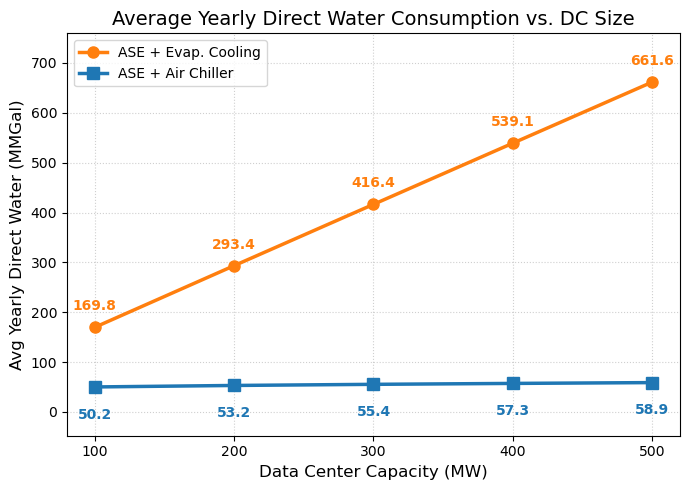

In [1]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration & Setup
# ==========================================
DC_Cap_base = 200.0
dc_multipliers = [0.50, 1.0, 1.5, 2.0, 2.5]
dc_sizes = DC_Cap_base .* dc_multipliers

# File names (same for both cases)
file_names = [
    "Results_DCSize_1_50pct.xlsx",
    "Results_DCSize_2_100pct.xlsx",
    "Results_DCSize_3_150pct.xlsx",
    "Results_DCSize_4_200pct.xlsx",
    "Results_DCSize_5_250pct.xlsx"
]

# Define the cases and their respective folder paths
# Adjust the "./" to your specific Case 1 folder path if it's not the current directory
cases = Dict(
    "ASE + Evap. Cooling"   => "./", 
    "ASE + Air Chiller" => "../DC_Size_Case_6/"
)

# ==========================================
# 2. Data Extraction Logic
# ==========================================
function get_avg_yearly_direct_water(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return 0.0
    end
    
    xf = XLSX.readxlsx(filepath)
    if "Water_Consumption" ∉ XLSX.sheetnames(xf)
        return 0.0
    end
    
    df = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    
    # Filter out the initial year 2025 to get accurate operational averages
    if "Year" in names(df)
        filter!(row -> row.Year != 2025, df)
    end
    
    n_years = nrow(df)
    if n_years == 0; return 0.0; end
    
    # Helper to find column index by partial string match (handles new MMGal headers automatically)
    function get_col_sum(name_part)
        c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
        return isnothing(c) ? 0.0 : sum(coalesce.(df[!, c], 0.0))
    end
    
    # Target all direct water columns
    direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    total_direct_water = sum(get_col_sum(k) for k in direct_keywords)
    
    # Return average yearly direct water
    return total_direct_water / n_years
end

# Extract data for all cases
results_data = Dict{String, Vector{Float64}}()

for (case_name, dir_path) in cases
    println(">>> Processing files for $case_name...")
    avg_waters = Float64[]
    
    for (i, fname) in enumerate(file_names)
        filepath = joinpath(dir_path, fname)
        avg_w = get_avg_yearly_direct_water(filepath)
        push!(avg_waters, avg_w)
        println("   -> Size: $(dc_sizes[i]) MW | Avg Yearly Direct Water: $(round(avg_w, digits=2)) MMGal")
    end
    results_data[case_name] = avg_waters
end

# ==========================================
# 3. Plotting
# ==========================================
fig, ax = PyPlot.subplots(figsize=(7, 5))

# Define distinct styles for each case to make the plot readable
plot_styles = Dict(
    "ASE + Evap. Cooling"   => Dict(:color => "#ff7f0e", :marker => "o", :y_offset => 10,  :va => "bottom"), # Orange
    "ASE + Air Chiller" => Dict(:color => "#1f77b4", :marker => "s", :y_offset => -15, :va => "top")     # Blue
)

for (case_name, avg_waters) in results_data
    style = plot_styles[case_name]
    
    # Plot Line and Markers
    ax.plot(dc_sizes, avg_waters, marker=style[:marker], linestyle="-", color=style[:color], 
            linewidth=2.5, markersize=8, label=case_name)

    # Add text annotations for each point
    for i in 1:length(dc_sizes)
        # Only annotate if the value is greater than 0 (or adjust as needed)
        ax.annotate(string(round(avg_waters[i], digits=1)), 
                    xy=(dc_sizes[i], avg_waters[i]), 
                    xytext=(0, style[:y_offset]), textcoords="offset points", 
                    ha="center", va=style[:va], fontsize=10, fontweight="bold", color=style[:color])
    end
end

ax.set_title("Average Yearly Direct Water Consumption vs. DC Size", fontsize=14)
ax.set_xlabel("Data Center Capacity (MW)", fontsize=12)
ax.set_ylabel("Avg Yearly Direct Water (MMGal)", fontsize=12)
ax.grid(true, linestyle=":", alpha=0.6)

# Force X-axis ticks to match our exact tested capacities
ax.set_xticks(dc_sizes)

# Adjust Y-axis limits slightly to ensure annotations aren't cut off
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - (y_max - y_min) * 0.1, y_max + (y_max - y_min) * 0.1)

ax.legend(loc="upper left")

PyPlot.tight_layout()
display(fig)

>>> Processing Data Center Size files for Electricity...

>>> Processing files for ASE + Evap. Cooling...
   -> Size: 100.0 MW | Avg Yearly Electricity: 933.7 GWh
   -> Size: 200.0 MW | Avg Yearly Electricity: 1461.0 GWh
   -> Size: 300.0 MW | Avg Yearly Electricity: 1988.0 GWh
   -> Size: 400.0 MW | Avg Yearly Electricity: 2514.8 GWh
   -> Size: 500.0 MW | Avg Yearly Electricity: 3041.5 GWh

>>> Processing files for ASE + Air Chiller...
   -> Size: 100.0 MW | Avg Yearly Electricity: 1005.6 GWh
   -> Size: 200.0 MW | Avg Yearly Electricity: 1604.3 GWh
   -> Size: 300.0 MW | Avg Yearly Electricity: 2202.6 GWh
   -> Size: 400.0 MW | Avg Yearly Electricity: 2800.6 GWh
   -> Size: 500.0 MW | Avg Yearly Electricity: 3398.6 GWh


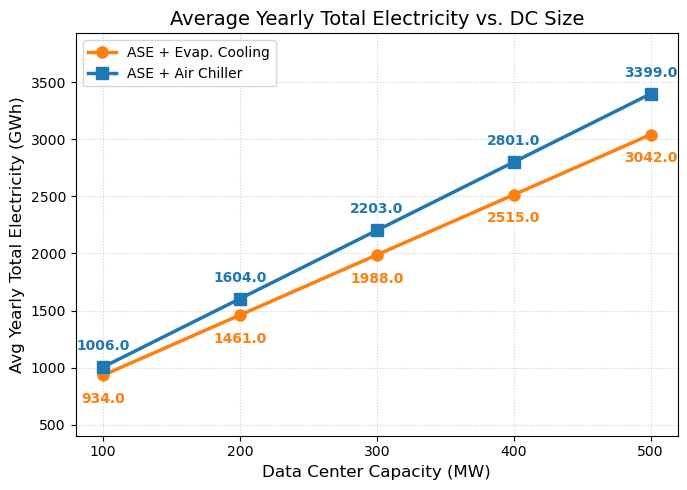

In [2]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration & Setup
# ==========================================
DC_Cap_base = 200.0
dc_multipliers = [0.50, 1.0, 1.5, 2.0, 2.5]
dc_sizes = DC_Cap_base .* dc_multipliers

# File names (same for both cases)
file_names = [
    "Results_DCSize_1_50pct.xlsx",
    "Results_DCSize_2_100pct.xlsx",
    "Results_DCSize_3_150pct.xlsx",
    "Results_DCSize_4_200pct.xlsx",
    "Results_DCSize_5_250pct.xlsx"
]

# Define the cases and their respective folder paths
cases = Dict(
    "ASE + Evap. Cooling"   => "./", 
    "ASE + Air Chiller" => "../DC_Size_Case_6/"
)

println(">>> Processing Data Center Size files for Electricity...")

# ==========================================
# 2. Data Extraction Logic
# ==========================================
function get_avg_yearly_electricity(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return 0.0
    end
    
    xf = XLSX.readxlsx(filepath)
    if "Generation_Summary" ∉ XLSX.sheetnames(xf)
        return 0.0
    end
    
    df = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
    
    # Filter out the initial year 2025 to get accurate operational averages
    if "Year" in names(df)
        filter!(row -> row.Year != 2025, df)
    end
    
    n_years = nrow(df)
    if n_years == 0; return 0.0; end
    
    # Sum all columns except 'Year' to get total system generation
    gen_cols = [c for c in names(df) if c != "Year"]
    total_elec_all_years = 0.0
    
    for c in gen_cols
        total_elec_all_years += sum(coalesce.(df[!, c], 0.0))
    end
    
    # Return average yearly total electricity (Values are already in GWh)
    return total_elec_all_years / n_years
end

# Extract data for all cases
results_data = Dict{String, Vector{Float64}}()

for (case_name, dir_path) in cases
    println("\n>>> Processing files for $case_name...")
    avg_elec = Float64[]
    
    for (i, fname) in enumerate(file_names)
        filepath = joinpath(dir_path, fname)
        avg_e = get_avg_yearly_electricity(filepath)
        push!(avg_elec, avg_e)
        println("   -> Size: $(dc_sizes[i]) MW | Avg Yearly Electricity: $(round(avg_e, digits=1)) GWh")
    end
    results_data[case_name] = avg_elec
end

# ==========================================
# 3. Plotting
# ==========================================
fig, ax = PyPlot.subplots(figsize=(7, 5))

# We only define colors and markers here. 
# We will calculate text offsets dynamically below.
plot_styles = Dict(
    "ASE + Evap. Cooling"   => Dict(:color => "#ff7f0e", :marker => "o"), # Orange
    "ASE + Air Chiller" => Dict(:color => "#1f77b4", :marker => "s")  # Blue
)

# 3A. Draw the lines and markers first
for (case_name, avg_elec) in results_data
    style = plot_styles[case_name]
    ax.plot(dc_sizes, avg_elec, marker=style[:marker], linestyle="-", color=style[:color], 
            linewidth=2.5, markersize=8, label=case_name)
end

# 3B. Dynamically place text annotations so they never cross
case_names = collect(keys(results_data))
if length(case_names) == 2
    name_A = case_names[1]
    name_B = case_names[2]
    
    for i in 1:length(dc_sizes)
        val_A = results_data[name_A][i]
        val_B = results_data[name_B][i]
        
        # Compare values: higher value text goes UP, lower value text goes DOWN
        if val_A >= val_B
            offset_A, va_A = 10, "bottom"
            offset_B, va_B = -12, "top"
        else
            offset_A, va_A = -12, "top"
            offset_B, va_B = 10, "bottom"
        end
        
        # Annotate A
        ax.annotate(string(round(val_A, digits=0)), 
                    xy=(dc_sizes[i], val_A), 
                    xytext=(0, offset_A), textcoords="offset points", 
                    ha="center", va=va_A, fontsize=10, fontweight="bold", color=plot_styles[name_A][:color])
                    
        # Annotate B
        ax.annotate(string(round(val_B, digits=0)), 
                    xy=(dc_sizes[i], val_B), 
                    xytext=(0, offset_B), textcoords="offset points", 
                    ha="center", va=va_B, fontsize=10, fontweight="bold", color=plot_styles[name_B][:color])
    end
end

ax.set_title("Average Yearly Total Electricity vs. DC Size", fontsize=14)
ax.set_xlabel("Data Center Capacity (MW)", fontsize=12)
ax.set_ylabel("Avg Yearly Total Electricity (GWh)", fontsize=12)
ax.grid(true, linestyle=":", alpha=0.6)

# Force X-axis ticks to match our exact tested capacities
ax.set_xticks(dc_sizes)

# Adjust Y-axis limits slightly to ensure annotations aren't cut off at the top/bottom
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)

ax.legend(loc="upper left")

PyPlot.tight_layout()
display(fig)

>>> Processing Data Center Size files for Total Cost...

>>> Processing files for ASE + Evap. Cooling...
   -> Size: 100.0 MW | Total System Cost: 1507.6 MM USD
   -> Size: 200.0 MW | Total System Cost: 2203.8 MM USD
   -> Size: 300.0 MW | Total System Cost: 2900.5 MM USD
   -> Size: 400.0 MW | Total System Cost: 3596.8 MM USD
   -> Size: 500.0 MW | Total System Cost: 4293.3 MM USD

>>> Processing files for ASE + Air Chiller...
   -> Size: 100.0 MW | Total System Cost: 1597.0 MM USD
   -> Size: 200.0 MW | Total System Cost: 2383.2 MM USD
   -> Size: 300.0 MW | Total System Cost: 3169.6 MM USD
   -> Size: 400.0 MW | Total System Cost: 3956.2 MM USD
   -> Size: 500.0 MW | Total System Cost: 4742.8 MM USD


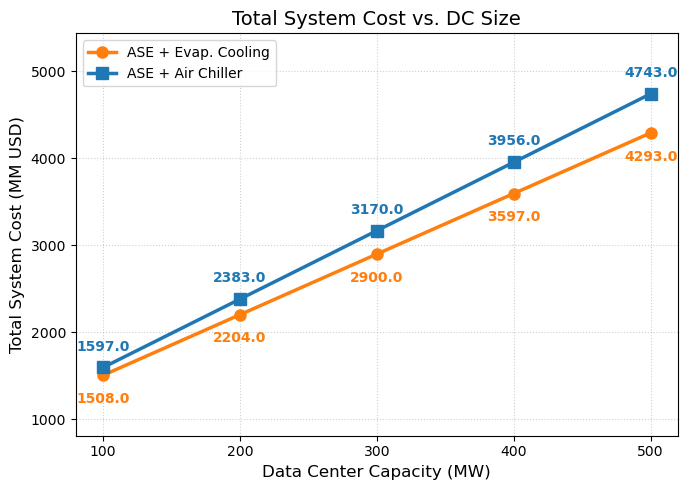

In [3]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration & Setup
# ==========================================
DC_Cap_base = 200.0
dc_multipliers = [0.50, 1.0, 1.5, 2.0, 2.5]
dc_sizes = DC_Cap_base .* dc_multipliers

# File names (same for both cases)
file_names = [
    "Results_DCSize_1_50pct.xlsx",
    "Results_DCSize_2_100pct.xlsx",
    "Results_DCSize_3_150pct.xlsx",
    "Results_DCSize_4_200pct.xlsx",
    "Results_DCSize_5_250pct.xlsx"
]

# Define the cases and their respective folder paths
cases = Dict(
    "ASE + Evap. Cooling"   => "./", 
    "ASE + Air Chiller" => "../DC_Size_Case_6/"
)

println(">>> Processing Data Center Size files for Total Cost...")

# ==========================================
# 2. Data Extraction Logic
# ==========================================
function get_total_system_cost(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return 0.0
    end
    
    xf = XLSX.readxlsx(filepath)
    if "Costs_summary" ∉ XLSX.sheetnames(xf)
        return 0.0
    end
    
    sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
    
    # Find "Total" row index
    total_row_cost_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
    
    val_cost = 0.0
    if !isnothing(total_row_cost_idx)
        # Sum Investment, O&M fix, O&M variable, and Decommissioning
        val_cost = Float64(sh_cost[total_row_cost_idx, 2]) + 
                   Float64(sh_cost[total_row_cost_idx, 3]) + 
                   Float64(sh_cost[total_row_cost_idx, 4]) + 
                   Float64(sh_cost[total_row_cost_idx, 5])
    else
        # Fallback: Sum the numeric values in columns 2 through 5
        for col in 2:5
            # Filter out any non-numeric strings before summing
            nums = filter(x -> x isa Number, sh_cost[!, col])
            val_cost += sum(coalesce.(nums, 0.0))
        end
    end
    
    # Values in the model are already in MM USD
    return val_cost
end

# Extract data for all cases
results_data = Dict{String, Vector{Float64}}()

for (case_name, dir_path) in cases
    println("\n>>> Processing files for $case_name...")
    costs = Float64[]
    
    for (i, fname) in enumerate(file_names)
        filepath = joinpath(dir_path, fname)
        total_c = get_total_system_cost(filepath)
        push!(costs, total_c)
        println("   -> Size: $(dc_sizes[i]) MW | Total System Cost: $(round(total_c, digits=1)) MM USD")
    end
    results_data[case_name] = costs
end

# ==========================================
# 3. Plotting
# ==========================================
fig, ax = PyPlot.subplots(figsize=(7, 5))

# We only define colors and markers here. 
# We will calculate text offsets dynamically below.
plot_styles = Dict(
    "ASE + Evap. Cooling"   => Dict(:color => "#ff7f0e", :marker => "o"), # Orange
    "ASE + Air Chiller" => Dict(:color => "#1f77b4", :marker => "s")  # Blue
)

# 3A. Draw the lines and markers first
for (case_name, costs) in results_data
    style = plot_styles[case_name]
    ax.plot(dc_sizes, costs, marker=style[:marker], linestyle="-", color=style[:color], 
            linewidth=2.5, markersize=8, label=case_name)
end

# 3B. Dynamically place text annotations so they never cross
case_names = collect(keys(results_data))
if length(case_names) == 2
    name_A = case_names[1]
    name_B = case_names[2]
    
    for i in 1:length(dc_sizes)
        val_A = results_data[name_A][i]
        val_B = results_data[name_B][i]
        
        # Compare values: higher value text goes UP, lower value text goes DOWN
        if val_A >= val_B
            offset_A, va_A = 10, "bottom"
            offset_B, va_B = -12, "top"
        else
            offset_A, va_A = -12, "top"
            offset_B, va_B = 10, "bottom"
        end
        
        # Annotate A (Formatted with commas for readability if numbers get large)
        ax.annotate(string(round(val_A, digits=0)), 
                    xy=(dc_sizes[i], val_A), 
                    xytext=(0, offset_A), textcoords="offset points", 
                    ha="center", va=va_A, fontsize=10, fontweight="bold", color=plot_styles[name_A][:color])
                    
        # Annotate B
        ax.annotate(string(round(val_B, digits=0)), 
                    xy=(dc_sizes[i], val_B), 
                    xytext=(0, offset_B), textcoords="offset points", 
                    ha="center", va=va_B, fontsize=10, fontweight="bold", color=plot_styles[name_B][:color])
    end
end

ax.set_title("Total System Cost vs. DC Size", fontsize=14)
ax.set_xlabel("Data Center Capacity (MW)", fontsize=12)
ax.set_ylabel("Total System Cost (MM USD)", fontsize=12)
ax.grid(true, linestyle=":", alpha=0.6)

# Force X-axis ticks to match our exact tested capacities
ax.set_xticks(dc_sizes)

# Adjust Y-axis limits slightly to ensure annotations aren't cut off at the top/bottom
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)

ax.legend(loc="upper left")

PyPlot.tight_layout()
display(fig)